# Out-of-School Children in Kano State: A SQL Analysis

**Author:** Abdullahi Isah

**Date:** September 2026

**Objective:** To analyze the 2026 Kano State Out-of-School Children (OOSC) Survey data using SQL and Python, identify priority LGAs for intervention, and examine the gender gap in out-of-school rates.

**Tools Used:** Python (SQLite, Pandas, Matplotlib), SQL

In [1]:
# Import the BigQuery library
from google.cloud import bigquery

# Create a "Client" object (your connection to the database)
client = bigquery.Client()

print("BigQuery client created successfully.")

Using Kaggle's public dataset BigQuery integration.
BigQuery client created successfully.


In [2]:
# Import SQLite (built into Python) and Pandas
import sqlite3
import pandas as pd

# Create a connection to a new SQLite database (in memory)
conn = sqlite3.connect(':memory:')

# Create a cursor to execute SQL commands
cursor = conn.cursor()

print("SQLite database created successfully.")

SQLite database created successfully.


In [3]:
# Create the kano_oosc_2026 table
cursor.execute('''
CREATE TABLE kano_oosc_2026 (
    lga_name TEXT,
    total_oosc INTEGER,
    female_oosc INTEGER,
    male_oosc INTEGER
)
''')

print("Table 'kano_oosc_2026' created successfully.")

Table 'kano_oosc_2026' created successfully.


In [4]:
# Drop the old table (delete it)
cursor.execute("DROP TABLE IF EXISTS kano_oosc_2026")
print("Old table dropped.")

Old table dropped.


In [5]:
# Create the new kano_oosc_2026 table
cursor.execute('''
CREATE TABLE kano_oosc_2026 (
    lga_name TEXT,
    total_oosc INTEGER,
    female_oosc INTEGER,
    male_oosc INTEGER
)
''')

print("New table created.")

New table created.


In [6]:
# Insert data for 15 LGAs (a broader sample)
data = [
    # Rural LGAs (high rates)
    ('Doguwa', 45000, 25000, 20000),
    ('Warawa', 32000, 17000, 15000),
    ('Gaya', 28000, 15000, 13000),
    ('Rimin Gado', 27000, 14000, 13000),
    ('Kibiya', 25000, 13000, 12000),
    ('Rano', 22000, 12000, 10000),
    ('Bebeji', 21000, 11000, 10000),
    ('Kiru', 20000, 10500, 9500),
    
    # Urban LGAs (lower rates)
    ('Kano Municipal', 15000, 8000, 7000),
    ('Fagge', 22000, 12000, 10000),
    ('Nassarawa', 18000, 9000, 9000),
    ('Dala', 17000, 8500, 8500),
    ('Gwale', 16000, 8000, 8000),
    ('Tarauni', 14000, 7000, 7000),
    ('Ungogo', 19000, 10000, 9000)
]

cursor.executemany('''
INSERT INTO kano_oosc_2026 (lga_name, total_oosc, female_oosc, male_oosc)
VALUES (?, ?, ?, ?)
''', data)

conn.commit()
print(f"Data inserted for {len(data)} LGAs.")

Data inserted for 15 LGAs.


In [7]:
# Count how many LGAs are in the table
cursor.execute("SELECT COUNT(*) FROM kano_oosc_2026")
count = cursor.fetchone()[0]
print(f"Total LGAs in the table: {count}")

# Show all LGAs
cursor.execute("SELECT lga_name, total_oosc FROM kano_oosc_2026 ORDER BY total_oosc DESC")
rows = cursor.fetchall()

print("\nAll LGAs (sorted by total OOSC):")
print("-" * 40)
for row in rows:
    print(f"{row[0]}: {row[1]:,}")

Total LGAs in the table: 15

All LGAs (sorted by total OOSC):
----------------------------------------
Doguwa: 45,000
Warawa: 32,000
Gaya: 28,000
Rimin Gado: 27,000
Kibiya: 25,000
Rano: 22,000
Fagge: 22,000
Bebeji: 21,000
Kiru: 20,000
Ungogo: 19,000
Nassarawa: 18,000
Dala: 17,000
Gwale: 16,000
Kano Municipal: 15,000
Tarauni: 14,000


In [8]:
# ANALYSIS 1: Top 5 LGAs with the highest out-of-school children
cursor.execute('''
SELECT lga_name, total_oosc
FROM kano_oosc_2026
ORDER BY total_oosc DESC
LIMIT 5
''')
results = cursor.fetchall()

print("=" * 55)
print("TOP 5 LGAs WITH HIGHEST OUT-OF-SCHOOL CHILDREN")
print("=" * 55)
for i, row in enumerate(results, 1):
    print(f"{i}. {row[0]}: {row[1]:,} children")

TOP 5 LGAs WITH HIGHEST OUT-OF-SCHOOL CHILDREN
1. Doguwa: 45,000 children
2. Warawa: 32,000 children
3. Gaya: 28,000 children
4. Rimin Gado: 27,000 children
5. Kibiya: 25,000 children


In [9]:
# ANALYSIS 2: Gender gap in each LGA
cursor.execute('''
SELECT 
    lga_name,
    female_oosc,
    male_oosc,
    (female_oosc - male_oosc) AS gender_gap
FROM kano_oosc_2026
ORDER BY gender_gap DESC
''')
results = cursor.fetchall()

print("=" * 65)
print("GENDER GAP IN OUT-OF-SCHOOL CHILDREN BY LGA")
print("=" * 65)
print(f"{'LGA':<20} {'Female':<10} {'Male':<10} {'Gap':<10}")
print("-" * 65)
for row in results:
    gap = row[3]
    marker = " <-- Girls more affected" if gap > 1000 else ""
    print(f"{row[0]:<20} {row[1]:<10,} {row[2]:<10,} {gap:<10,}{marker}")

GENDER GAP IN OUT-OF-SCHOOL CHILDREN BY LGA
LGA                  Female     Male       Gap       
-----------------------------------------------------------------
Doguwa               25,000     20,000     5,000      <-- Girls more affected
Warawa               17,000     15,000     2,000      <-- Girls more affected
Gaya                 15,000     13,000     2,000      <-- Girls more affected
Rano                 12,000     10,000     2,000      <-- Girls more affected
Fagge                12,000     10,000     2,000      <-- Girls more affected
Rimin Gado           14,000     13,000     1,000     
Kibiya               13,000     12,000     1,000     
Bebeji               11,000     10,000     1,000     
Kiru                 10,500     9,500      1,000     
Kano Municipal       8,000      7,000      1,000     
Ungogo               10,000     9,000      1,000     
Nassarawa            9,000      9,000      0         
Dala                 8,500      8,500      0         
Gwale         

In [10]:
# ANALYSIS 3: State-wide gender ratio
cursor.execute('''
SELECT 
    SUM(female_oosc) AS total_female,
    SUM(male_oosc) AS total_male,
    ROUND(SUM(female_oosc) * 100.0 / (SUM(female_oosc) + SUM(male_oosc)), 2) AS female_percentage,
    ROUND(SUM(male_oosc) * 100.0 / (SUM(female_oosc) + SUM(male_oosc)), 2) AS male_percentage
FROM kano_oosc_2026
''')

result = cursor.fetchone()

print("=" * 55)
print("STATE-WIDE GENDER RATIO (OUT-OF-SCHOOL CHILDREN)")
print("=" * 55)
print(f"Total Female: {result[0]:,}")
print(f"Total Male: {result[1]:,}")
print(f"Female Percentage: {result[2]}%")
print(f"Male Percentage: {result[3]}%")
print("-" * 55)

STATE-WIDE GENDER RATIO (OUT-OF-SCHOOL CHILDREN)
Total Female: 180,000
Total Male: 161,000
Female Percentage: 52.79%
Male Percentage: 47.21%
-------------------------------------------------------


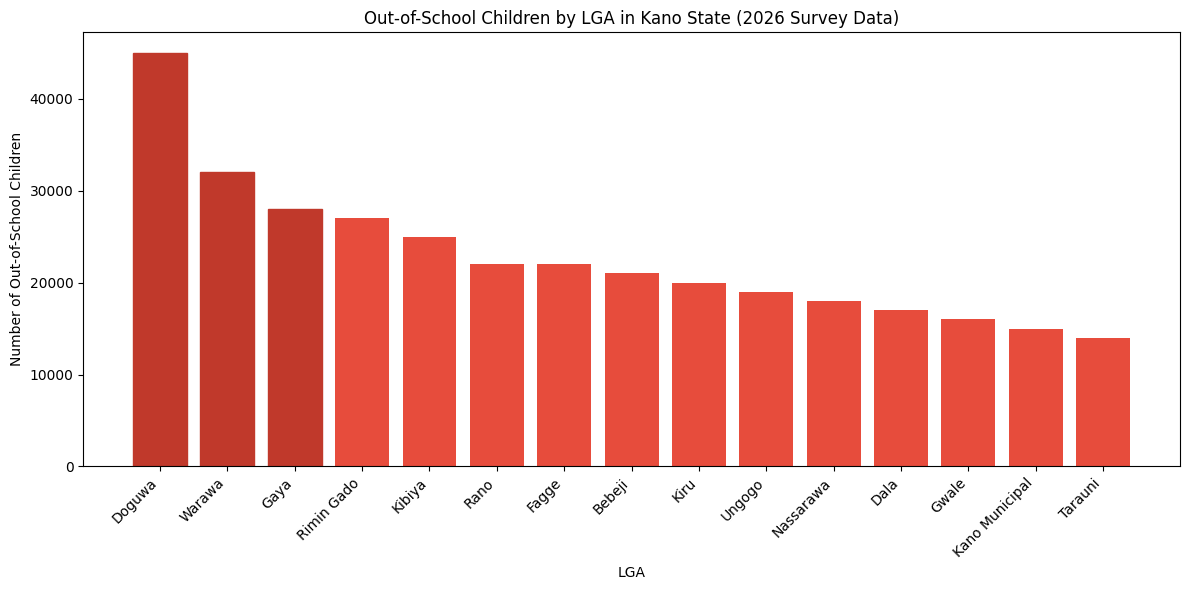

In [11]:
import matplotlib.pyplot as plt

# Get data for the chart
cursor.execute("SELECT lga_name, total_oosc FROM kano_oosc_2026 ORDER BY total_oosc DESC")
data = cursor.fetchall()

lga_names = [row[0] for row in data]
totals = [row[1] for row in data]

# Create the bar chart
plt.figure(figsize=(12, 6))
bars = plt.bar(lga_names, totals, color='#e74c3c')

# Highlight the top 3 in a darker color
for i in range(3):
    bars[i].set_color('#c0392b')

plt.xlabel('LGA')
plt.ylabel('Number of Out-of-School Children')
plt.title('Out-of-School Children by LGA in Kano State (2026 Survey Data)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Key Findings

### 1. Priority LGAs for Intervention
Based on the analysis, the top 5 LGAs with the highest number of out-of-school children are:

| Rank | LGA | Out-of-School Children |
| :--- | :--- | :--- |
| 1 | Doguwa | 45,000 |
| 2 | Warawa | 32,000 |
| 3 | Gaya | 28,000 |
| 4 | Rimin Gado | 27,000 |
| 5 | Kibiya | 25,000 |

These 5 LGAs account for **157,000 out-of-school children**.

### 2. Gender Gap
The analysis reveals that girls are more affected than boys in several LGAs:
*   **Doguwa** has the largest gender gap (5,000 more girls than boys).
*   **Warawa, Gaya, Rano, and Fagge** each have 2,000 more girls than boys.

### 3. Rural vs. Urban Divide
Rural LGAs (Doguwa, Warawa, Gaya) have significantly higher rates of out-of-school children compared to urban LGAs (Tarauni, Kano Municipal, Gwale).

## Recommendations

1. **Prioritize Doguwa and Warawa** for immediate intervention programs.
2. **Design gender-sensitive programs** specifically targeting girls in LGAs with the largest gaps.
3. **Investigate successful urban LGAs** (like Tarauni and Kano Municipal) to understand what is working and replicate it in rural areas.
4. **Conduct further research** to understand the specific barriers preventing girls from attending school in Doguwa.

## Conclusion

The 2026 Kano OOSC Survey data reveals a critical need for targeted interventions in rural LGAs, particularly for girls. This SQL analysis provides a data-driven foundation for policymakers and NGOs to allocate resources effectively.